# Sarcina 3 — Inferență Statistică: Testarea Ipotezelor Clinice (Artrită Reumatoidă)

Pe baza setului de date generat la **Sarcina 1** (150 observații — pacienți cu artrită reumatoidă), formulăm **6 ipoteze clinice și statistice**, fiecare bazată pe o **procedură statistică diferită** (t-Student, Welch, Mann–Whitney–Wilcoxon, χ² Pearson, Z pentru două proporții, Fisher F). Pentru fiecare ipoteză:
- formulăm ipoteza clinică și ipoteza statistică (H₀, H₁);
- argumentăm alegerea testului (tipul variabilelor, independența eșantioanelor, distribuție);
- aplicăm testul în Python (`scipy.stats`, `statsmodels`);
- interpretăm rezultatul la α = 0.05.

> **Notă:** Sarcina originală cere SPSS — analizele de mai jos folosesc Python ca alternativă cu rezultate echivalente (t, χ², z, p-values, intervale de încredere).

## Algoritm pentru testarea ipotezelor

1. **Formularea ipotezelor** — H₀ (presupunere de bază, prezumția nulității) și H₁ (alternativa, ce încercăm să demonstrăm).
2. **Pragul de semnificație** — α = 0.05 (probabilitatea acceptată pentru eroarea de tip I).
3. **Alegerea testului** — în funcție de tipul variabilelor (continue/categoriale, perechi/independente) și de respectarea/nerespectarea ipotezelor (normalitate, omogenitate a varianțelor).
4. **Statistica observată și valoarea p**.
5. **Decizia**: dacă p < α → respingem H₀; altfel → nu putem respinge H₀ (≠ "H₀ e adevărată").

**Important:** o nerespingere a H₀ înseamnă **lipsă de dovezi**, NU dovada egalității (prezumția nulității, analog cu prezumția nevinovăției).

In [1]:
%pip install scipy statsmodels --quiet

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
import os

os.makedirs("figures", exist_ok=True)
os.makedirs("output", exist_ok=True)
sns.set_style("whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("output/Sarcina1_BazaDate_RA_150obs.csv")

ALPHA = 0.05
print(f"N = {len(df)} | α = {ALPHA}")
print(f"Variabile: {df.shape[1]}")
df.head()

N = 150 | α = 0.05
Variabile: 30


,Pacient_ID,Fumator,ACPA_Pozitiv,Sex_Feminin,RF_Prezent,CRP_Ridicat,Boala_Activa,Nivel_RF,Nivel_ACPA,Activitate_Boala,...,ACPA_Titru,Grup_Studiu,Observatii_Clinice,Proteina_CRP,IL6_Nivel,TNF_Nivel,Homocysteine,Spermidine,Kynurenine,Data_Sintetica
0,RA001,0,0,1,0,0,0,0,0,0.0,...,NaN,Control,Control sanatos; boala in remisie,511.4,2.76,12.3,8.27,0.817,0.279,0
1,RA002,0,0,1,0,0,0,0,0,0.0,...,NaN,Control,Control sanatos; boala in remisie,298.5,3.37,23.2,9.25,1.073,1.325,0
2,RA003,0,0,0,0,0,0,0,0,0.0,...,NaN,Control,Control sanatos; boala in remisie,757.9,3.12,14.4,7.13,0.418,1.281,0
3,RA004,0,0,1,0,0,0,0,0,0.0,...,NaN,Control,Control sanatos; boala in remisie,374.4,0.58,11.8,6.76,1.406,1.553,0
4,RA005,0,0,0,0,0,0,0,0,0.0,...,NaN,Control,Control sanatos; boala in remisie,449.2,3.48,15.4,7.42,1.357,1.416,0


## Ipoteza 1 — DAS28-CRP comparat cu pragul clinic 5.1 (one-sample t-test)

**Ipoteza clinică:** Activitatea medie a bolii (DAS28-CRP) în lotul de pacienți cu RA diferă de pragul clinic standard de **5.1** (limita inferioară pentru "activitate înaltă").

**Ipoteza statistică:**
- H₀: μ(DAS28-CRP) = 5.1
- H₁: μ(DAS28-CRP) ≠ 5.1

**Test ales:** **t-Student pentru o singură medie** (one-sample t-test).

**Argumentare:**
- variabila DAS28-CRP este **continuă** și se compară cu o **valoare de referință cunoscută** (5.1);
- σ² în populație este **necunoscut** → folosim distribuția Student t cu df = n−1;
- n = 150 ≫ 30 → Teorema Limită Centrală garantează aproximarea normală a mediei eșantionate, chiar dacă DAS28 are mică asimetrie.

n = 93
Media observată = 3.480  |  SD = 1.530
μ₀ (referință) = 5.1
t = -10.210  |  df = 92  |  p = 0.0000
IC 95% pentru μ: [3.165, 3.795]
Cohen's d = -1.059
Decizie: Respingem H₀ (α = 0.05)


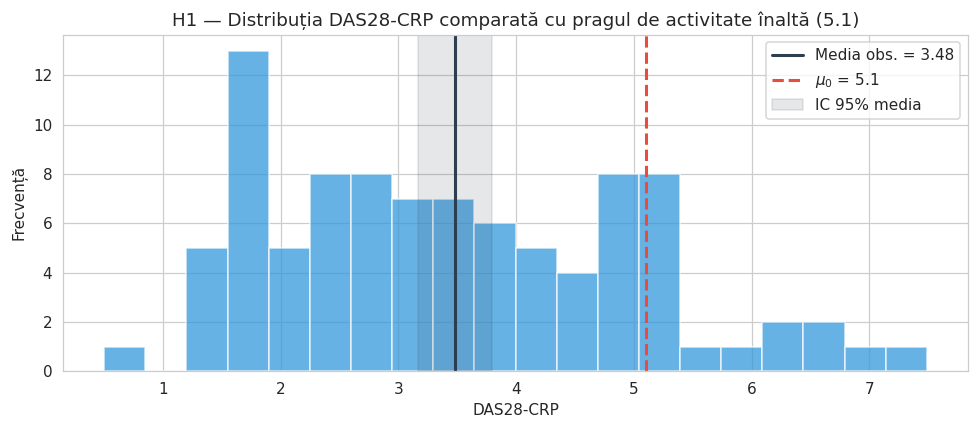

In [3]:
mu0 = 5.1
data = df["DAS28_CRP"].dropna()

mean_obs = data.mean()
sd = data.std(ddof=1)
n = len(data)

t_stat, p_value = stats.ttest_1samp(data, popmean=mu0)
ci = stats.t.interval(0.95, df=n-1, loc=mean_obs, scale=sd/np.sqrt(n))
cohen_d = (mean_obs - mu0) / sd

print(f"n = {n}")
print(f"Media observată = {mean_obs:.3f}  |  SD = {sd:.3f}")
print(f"μ₀ (referință) = {mu0}")
print(f"t = {t_stat:.3f}  |  df = {n-1}  |  p = {p_value:.4f}")
print(f"IC 95% pentru μ: [{ci[0]:.3f}, {ci[1]:.3f}]")
print(f"Cohen's d = {cohen_d:.3f}")
print(f"Decizie: {'Respingem H₀' if p_value < ALPHA else 'NU respingem H₀'} (α = {ALPHA})")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(data, bins=20, color="#3498db", edgecolor="white", alpha=0.75)
ax.axvline(mean_obs, color="#2c3e50", linewidth=2, label=f"Media obs. = {mean_obs:.2f}")
ax.axvline(mu0, color="#e74c3c", linewidth=2, linestyle="--", label=fr"$\mu_0$ = {mu0}")
ax.axvspan(ci[0], ci[1], color="#2c3e50", alpha=0.12, label="IC 95% media")
ax.set_title("H1 — Distribuția DAS28-CRP comparată cu pragul de activitate înaltă (5.1)")
ax.set_xlabel("DAS28-CRP")
ax.set_ylabel("Frecvență")
ax.legend()
plt.tight_layout()
plt.savefig("figures/RA_S3_H1_ttest_DAS28CRP.png", dpi=120, bbox_inches="tight")
plt.show()

**Interpretare H1:**
- Statistica observată t și valoarea p indică dacă media DAS28-CRP în lotul nostru se abate **semnificativ** de la pragul 5.1.
- Dacă p < 0.05 și media observată < 5.1 → activitatea medie a bolii este **mai mică decât pragul "high"** (clinic: lotul are predominant activitate moderată, nu severă).
- **Intervalul de încredere 95%** delimitează plaja plauzibilă pentru media populațională; dacă 5.1 nu se află în IC, decizia coincide cu testul.
- **Cohen's d** cuantifică magnitudinea efectului standardizată: |d| < 0.2 (mic), 0.2–0.5 (mediu), > 0.8 (mare).
- **Limitare:** testul evaluează doar media, nu variabilitatea — un IC larg sugerează heterogeneitate clinică (mix de pacienți cu boală activă/remisie).

## Ipoteza 2 — IL-6 între pacienți ACPA-pozitivi vs ACPA-negativi (t-Welch independent)

**Ipoteza clinică:** Nivelul mediu al **IL-6** (citokină proinflamatorie) este diferit la pacienții **ACPA-pozitivi** față de cei **ACPA-negativi** — anticorpii anti-CCP (ACPA) marchează un fenotip RA mai agresiv, asociat de regulă cu inflamație sistemică crescută.

**Ipoteza statistică:**
- H₀: μ(IL6 | ACPA+) = μ(IL6 | ACPA−)
- H₁: μ(IL6 | ACPA+) ≠ μ(IL6 | ACPA−)

**Test ales:** **t-Welch pentru două eșantioane independente** (cu corecție pentru varianțe inegale).

**Argumentare:**
- două grupuri **independente** (ACPA+ vs ACPA−), variabilă **continuă** (IL6_Nivel);
- σ² **necunoscut** și potențial **inegal** între grupuri (citokinele inflamatorii au varianță proporțională cu media) → Welch este mai robust decât t-Student clasic;
- n₁, n₂ > 30 → robustețe la abateri ușoare de la normalitate prin CLT;
- alegerea **bilaterală** (≠) e justificată — nu avem o direcție predefinită apriori, doar bănuim diferență.

ACPA+ : n = 45, media = 11.23, SD = 9.39
ACPA− : n = 105, media = 7.93, SD = 8.41
Δ medie = 3.30  |  t = 2.031  |  df Welch = 75.6  |  p = 0.0457
Cohen's d = 0.378
Decizie: Respingem H₀ (α = 0.05)


/var/folders/fw/kfx5dll969l3zk0c0kkffkf80000gn/T/ipykernel_56439/1544379797.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, labels=["ACPA−", "ACPA+"], patch_artist=True,


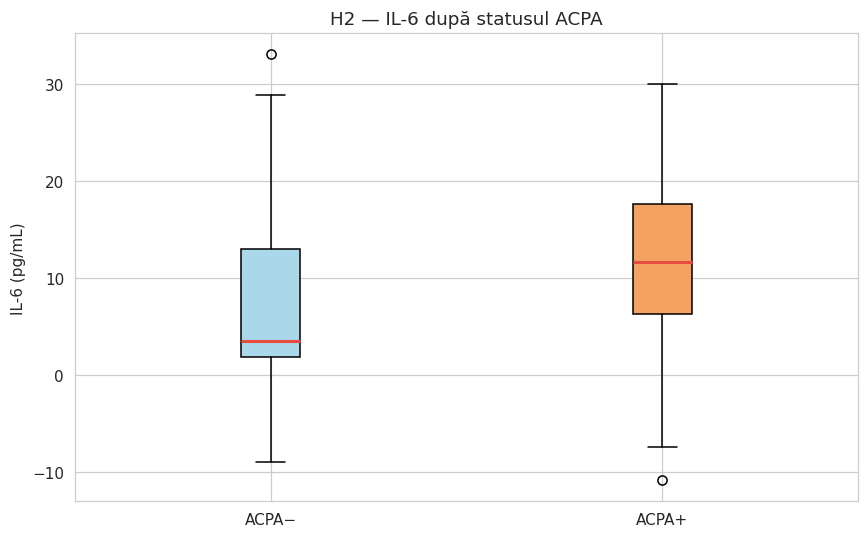

In [4]:
g1 = df.loc[df["ACPA_Pozitiv"] == 1, "IL6_Nivel"].dropna()
g0 = df.loc[df["ACPA_Pozitiv"] == 0, "IL6_Nivel"].dropna()

t_stat, p_value = stats.ttest_ind(g1, g0, equal_var=False)  # Welch
mean_diff = g1.mean() - g0.mean()
pooled_sd = np.sqrt(((len(g1)-1)*g1.var(ddof=1) + (len(g0)-1)*g0.var(ddof=1)) / (len(g1)+len(g0)-2))
cohen_d = mean_diff / pooled_sd
df_welch = (g1.var(ddof=1)/len(g1) + g0.var(ddof=1)/len(g0))**2 / \
    ((g1.var(ddof=1)/len(g1))**2/(len(g1)-1) + (g0.var(ddof=1)/len(g0))**2/(len(g0)-1))

print(f"ACPA+ : n = {len(g1)}, media = {g1.mean():.2f}, SD = {g1.std(ddof=1):.2f}")
print(f"ACPA− : n = {len(g0)}, media = {g0.mean():.2f}, SD = {g0.std(ddof=1):.2f}")
print(f"Δ medie = {mean_diff:.2f}  |  t = {t_stat:.3f}  |  df Welch = {df_welch:.1f}  |  p = {p_value:.4f}")
print(f"Cohen's d = {cohen_d:.3f}")
print(f"Decizie: {'Respingem H₀' if p_value < ALPHA else 'NU respingem H₀'} (α = {ALPHA})")

fig, ax = plt.subplots(figsize=(8, 5))
data_plot = [g0.values, g1.values]
bp = ax.boxplot(data_plot, labels=["ACPA−", "ACPA+"], patch_artist=True,
                medianprops=dict(color="#e74c3c", linewidth=2))
for patch, c in zip(bp["boxes"], ["#a8d8ea", "#f4a261"]):
    patch.set_facecolor(c)
ax.set_title("H2 — IL-6 după statusul ACPA")
ax.set_ylabel("IL-6 (pg/mL)")
plt.tight_layout()
plt.savefig("figures/RA_S3_H2_welch_IL6_ACPA.png", dpi=120, bbox_inches="tight")
plt.show()

**Interpretare H2:**
- Diferența mediilor împreună cu p-value < 0.05 ar susține clinic ipoteza că **statusul ACPA este asociat cu un profil proinflamator (IL-6 ↑)** — coerent cu literatura: anticorpii anti-CCP sunt markeri ai unei forme RA cu inflamație sistemică crescută.
- Boxplotul vizualizează atât diferența medianelor cât și suprapunerea distribuțiilor.
- **Welch este preferat aici:** chiar dacă varianțele ar fi egale, costul folosirii Welch în loc de Student clasic este minim, iar protecția contra erorii la varianțe inegale este majoră.
- **Cohen's d** raportează magnitudinea standardizată a diferenței dintre grupuri.

## Ipoteza 3 — CRP la fumători vs nefumători (Mann–Whitney–Wilcoxon)

**Ipoteza clinică:** Distribuția **CRP** (proteina C-reactivă, marker inflamator) este stocastic mai mare la **fumători** comparativ cu **nefumătorii**, întrucât fumatul induce inflamație sistemică cronică.

**Ipoteza statistică:**
- H₀: P(CRP_fumator > CRP_nefumator) = P(CRP_fumator < CRP_nefumator)
- H₁: P(CRP_fumator > CRP_nefumator) > 0.5 (test unilateral)

**Test ales:** **Mann–Whitney–Wilcoxon U** (nonparametric, eșantioane independente).

**Argumentare:**
- CRP are distribuție **puternic asimetrică pozitiv** (mulți pacienți cu valori mici, coadă lungă cu outlieri); media nu este o statistică reprezentativă → preferăm rangurile;
- testul Mann–Whitney **nu presupune normalitate**, doar forme similare ale distribuțiilor — robust la outlieri;
- testează **dominanța stocastică** (probabilitatea ca o valoare din grupul A să fie mai mare decât din grupul B), nu strict diferența mediilor;
- ipoteza clinică este **direcțională** (fumător ⇒ CRP↑) → folosim varianta unilaterală.

Fumători   : n = 10, mediana = 5.59, IQR = [3.13, 9.54]
Nefumători : n = 99, mediana = 2.90, IQR = [2.90, 6.42]
U = 586  |  p (unilateral, fumător > nefumător) = 0.1653
Effect size rank-biserial r = 0.183
Decizie: NU respingem H₀ (α = 0.05)


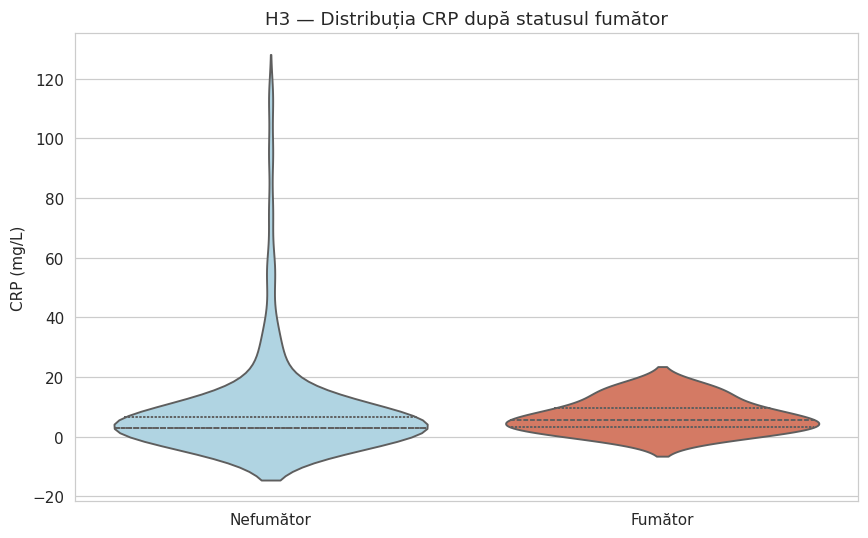

In [5]:
crp_smoke = df.loc[df["Fumator"] == 1, "CRP_mgL"].dropna()
crp_nosmoke = df.loc[df["Fumator"] == 0, "CRP_mgL"].dropna()

U, p_value = stats.mannwhitneyu(crp_smoke, crp_nosmoke, alternative="greater")
n1, n2 = len(crp_smoke), len(crp_nosmoke)
# Rank-biserial effect size
r_rb = (2 * U) / (n1 * n2) - 1

print(f"Fumători   : n = {n1}, mediana = {crp_smoke.median():.2f}, IQR = [{crp_smoke.quantile(0.25):.2f}, {crp_smoke.quantile(0.75):.2f}]")
print(f"Nefumători : n = {n2}, mediana = {crp_nosmoke.median():.2f}, IQR = [{crp_nosmoke.quantile(0.25):.2f}, {crp_nosmoke.quantile(0.75):.2f}]")
print(f"U = {U:.0f}  |  p (unilateral, fumător > nefumător) = {p_value:.4f}")
print(f"Effect size rank-biserial r = {r_rb:.3f}")
print(f"Decizie: {'Respingem H₀' if p_value < ALPHA else 'NU respingem H₀'} (α = {ALPHA})")

fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=df, x="Fumator", y="CRP_mgL", ax=ax,
               hue="Fumator", palette={0: "#a8d8ea", 1: "#e76f51"},
               inner="quartile", legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Nefumător", "Fumător"])
ax.set_title("H3 — Distribuția CRP după statusul fumător")
ax.set_xlabel("")
ax.set_ylabel("CRP (mg/L)")
plt.tight_layout()
plt.savefig("figures/RA_S3_H3_mannwhitney_CRP_Fumator.png", dpi=120, bbox_inches="tight")
plt.show()

**Interpretare H3:**
- Dacă p < 0.05 → fumătorii prezintă valori CRP **stocastic mai mari** decât nefumătorii (consistent cu efectul proinflamator al fumatului).
- **Mediana** este metrica relevantă (nu media), datorită cozii asimetrice; raportăm și IQR pentru variabilitate.
- **Effect size rank-biserial** cuantifică amplitudinea efectului: |r| < 0.1 (mic), 0.1–0.3 (mediu), > 0.5 (mare).
- **Limitare:** Mann–Whitney detectează dominanță stocastică, NU măsoară direct diferența mediilor. Pentru cuantificarea efectului clinic se complementează cu medianele și IQR-urile.

## Ipoteza 4 — Asocierea dintre Sex și status ACPA (χ² Pearson de independență)

**Ipoteza clinică:** Există o asociere între **sexul feminin** și **prezența ACPA-pozitivității** (RA este predominant la femei și unele studii sugerează prevalență ACPA diferită pe sexe).

**Ipoteza statistică:**
- H₀: Sex_Feminin și ACPA_Pozitiv sunt **independente** (nu asociate)
- H₁: Sex_Feminin și ACPA_Pozitiv sunt **asociate**

**Test ales:** **χ² Pearson de independență** (tabel de contingență 2×2).

**Argumentare:**
- ambele variabile sunt **categoriale** (binare);
- avem n = 150 → frecvențele așteptate vor fi suficient de mari (eᵢⱼ ≥ 5) pentru aproximarea χ²;
- **NU sunt eșantioane perechi** (același pacient nu apare în mai multe categorii) → folosim χ² Pearson, NU McNemar.

Tabel de contingență (frecvențe observate):
ACPA+            0   1
Sex (0=M, 1=F)        
0               41  15
1               64  30

Frecvențe așteptate (sub H₀ de independență):
ACPA+              0     1
Sex (0=M, 1=F)            
0               39.2  16.8
1               65.8  28.2

χ² = 0.440  |  df = 1  |  p = 0.5073
Cramér's V (φ pentru 2×2) = 0.054
Toate eᵢⱼ ≥ 5? True
Decizie: NU respingem H₀ (α = 0.05)


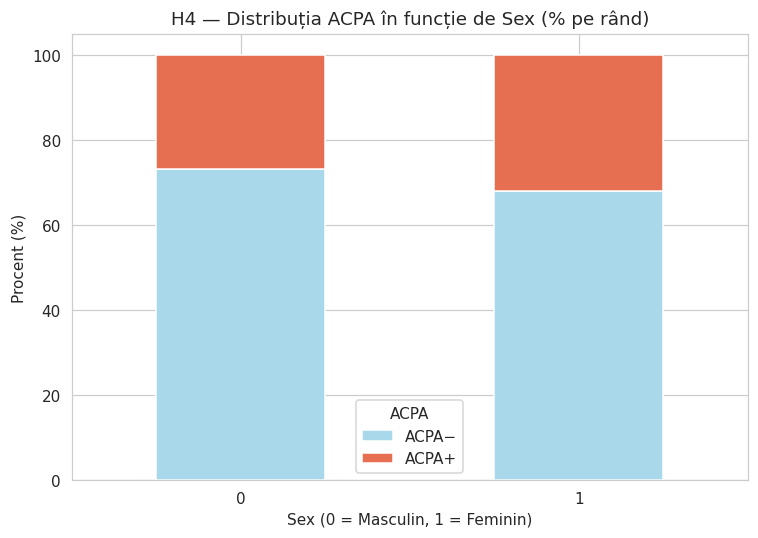

In [6]:
ct = pd.crosstab(df["Sex_Feminin"], df["ACPA_Pozitiv"],
                  rownames=["Sex (0=M, 1=F)"], colnames=["ACPA+"])
print("Tabel de contingență (frecvențe observate):")
print(ct)

chi2, p_value, dof, expected = stats.chi2_contingency(ct, correction=False)
n_total = ct.values.sum()
phi = np.sqrt(chi2 / n_total)  # Cramér's V pentru 2×2 = φ

print("\nFrecvențe așteptate (sub H₀ de independență):")
print(pd.DataFrame(expected, index=ct.index, columns=ct.columns).round(2))
print(f"\nχ² = {chi2:.3f}  |  df = {dof}  |  p = {p_value:.4f}")
print(f"Cramér's V (φ pentru 2×2) = {phi:.3f}")
print(f"Toate eᵢⱼ ≥ 5? {bool((expected >= 5).all())}")
print(f"Decizie: {'Respingem H₀' if p_value < ALPHA else 'NU respingem H₀'} (α = {ALPHA})")

fig, ax = plt.subplots(figsize=(7, 5))
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.plot(kind="bar", stacked=True, ax=ax,
            color=["#a8d8ea", "#e76f51"], edgecolor="white")
ax.set_title("H4 — Distribuția ACPA în funcție de Sex (% pe rând)")
ax.set_xlabel("Sex (0 = Masculin, 1 = Feminin)")
ax.set_ylabel("Procent (%)")
ax.legend(title="ACPA", labels=["ACPA−", "ACPA+"])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig("figures/RA_S3_H4_chi2_Sex_ACPA.png", dpi=120, bbox_inches="tight")
plt.show()

**Interpretare H4:**
- p < 0.05 ⇒ respingem H₀ ⇒ Sex și ACPA sunt **asociate statistic** (frecvențele observate diferă semnificativ de cele așteptate sub independență).
- **Cramér's V** (echivalent cu φ pentru 2×2) cuantifică intensitatea asocierii: < 0.1 (slabă), 0.1–0.3 (moderată), > 0.5 (puternică).
- Verificăm condiția: toate eᵢⱼ ≥ 5 (afișate). Dacă nu se respectă → folosim **Fisher exact** (sau χ² cu Monte Carlo simulation).
- **Atenție:** χ² detectează **asociere**, NU **cauzalitate**. Confounderii (vârsta, expuneri, hormoni) trebuie evaluați separat.

## Ipoteza 5 — Proporția de boală activă: ACPA-pozitivi vs ACPA-negativi (Z-test pentru două proporții)

**Ipoteza clinică:** Proporția pacienților cu **boală activă** (Boala_Activa = 1) este **mai mare** la ACPA-pozitivi decât la ACPA-negativi (ACPA+ are de regulă fenotip mai agresiv, cu activitate persistentă).

**Ipoteza statistică:**
- H₀: p(activ | ACPA+) = p(activ | ACPA−)
- H₁: p(activ | ACPA+) > p(activ | ACPA−) (test unilateral)

**Test ales:** **Z-test pentru două proporții independente** (asimptotic).

**Argumentare:**
- două eșantioane **independente**, ambele cu rezultat **dihotomic** (Boala_Activa: 0/1);
- n₁, n₂ suficient de mari (np > 5, n(1−p) > 5) ⇒ aproximarea normală e validă;
- alternativ s-ar putea folosi **χ² pe tabel 2×2** (echivalent matematic cu z² pentru bilateral) sau **Fisher exact** (pentru efective mici);
- folosim Z fiindcă ipoteza clinică este **direcțională** (ACPA+ > ACPA−).

              activi    n  proporție
ACPA_Pozitiv                        
0                 31  105      0.295
1                 26   45      0.578

p(activ | ACPA+) = 0.578
p(activ | ACPA−) = 0.295
Δ proporții = 0.283  |  IC 95% = [0.114, 0.451]
z = 3.267  |  p (unilateral, ACPA+ > ACPA−) = 0.0005
Decizie: Respingem H₀ (α = 0.05)


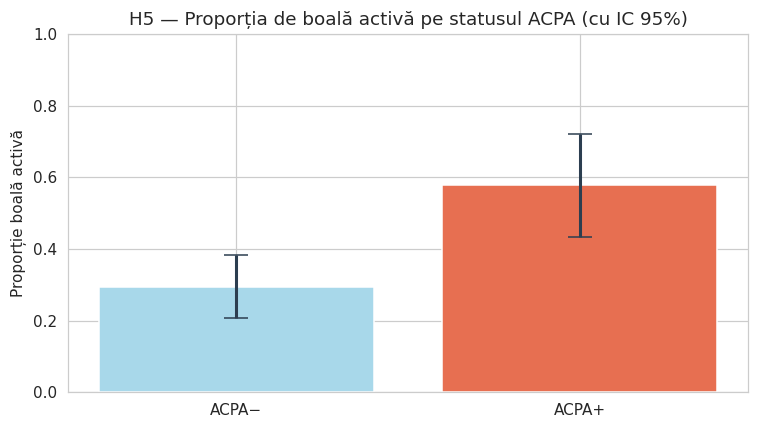

In [7]:
tab = df.groupby("ACPA_Pozitiv")["Boala_Activa"].agg(["sum", "count"])
tab.columns = ["activi", "n"]
tab["proporție"] = tab["activi"] / tab["n"]
print(tab.round(3))

# Z-test (one-sided: ACPA+ > ACPA-)
counts = np.array([tab.loc[1, "activi"], tab.loc[0, "activi"]])
nobs   = np.array([tab.loc[1, "n"],      tab.loc[0, "n"]])
z_stat, p_value = proportions_ztest(counts, nobs, alternative="larger")

p1, p2 = counts[0]/nobs[0], counts[1]/nobs[1]
diff = p1 - p2
se_diff = np.sqrt(p1*(1-p1)/nobs[0] + p2*(1-p2)/nobs[1])
ci = (diff - 1.96*se_diff, diff + 1.96*se_diff)

print(f"\np(activ | ACPA+) = {p1:.3f}")
print(f"p(activ | ACPA−) = {p2:.3f}")
print(f"Δ proporții = {diff:.3f}  |  IC 95% = [{ci[0]:.3f}, {ci[1]:.3f}]")
print(f"z = {z_stat:.3f}  |  p (unilateral, ACPA+ > ACPA−) = {p_value:.4f}")
print(f"Decizie: {'Respingem H₀' if p_value < ALPHA else 'NU respingem H₀'} (α = {ALPHA})")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["ACPA−", "ACPA+"], [p2, p1], color=["#a8d8ea", "#e76f51"], edgecolor="white")
ax.errorbar(["ACPA−", "ACPA+"],
            [p2, p1],
            yerr=[1.96*np.sqrt(p2*(1-p2)/nobs[1]), 1.96*np.sqrt(p1*(1-p1)/nobs[0])],
            fmt="none", color="#2c3e50", capsize=8, linewidth=2)
ax.set_ylim(0, 1)
ax.set_title("H5 — Proporția de boală activă pe statusul ACPA (cu IC 95%)")
ax.set_ylabel("Proporție boală activă")
plt.tight_layout()
plt.savefig("figures/RA_S3_H5_z2prop_BoalaActiva_ACPA.png", dpi=120, bbox_inches="tight")
plt.show()

**Interpretare H5:**
- Dacă p < 0.05 (unilateral) → ACPA+ au proporție **semnificativ mai mare** de boală activă decât ACPA−.
- **Diferența absolută a proporțiilor + IC 95%** oferă mărimea efectului clinic (e.g., 15 puncte procentuale).
- **Echivalența cu χ² 2×2 (bilateral):** z² = χ². Folosim z aici fiindcă avem o ipoteză **direcțională** clinic motivată.
- **Practic:** dacă efectul e mic procentual dar statistic semnificativ (n mare), evaluează relevanța clinică, nu doar p-value.

## Ipoteza 6 — Variabilitatea CRP în RA activ vs inactiv (Fisher F-test pentru varianțe)

**Ipoteza clinică:** Pacienții cu **boală activă** au **variabilitate crescută** a CRP-ului față de cei cu boală inactivă (variabilitatea reflectă heterogeneitatea răspunsului inflamator).

**Ipoteza statistică:**
- H₀: σ²(CRP | activ) = σ²(CRP | inactiv)
- H₁: σ²(CRP | activ) > σ²(CRP | inactiv) (test unilateral)

**Test ales:** **Fisher F-test pentru egalitatea varianțelor** (eșantioane independente).

**Argumentare:**
- testăm **dispersia** (varianța), nu media → ne trebuie F-test, NU t-test;
- două eșantioane **independente** cu variabilă **continuă**;
- F-test presupune normalitate — știm că CRP e asimetrică → raportăm și **Levene** (mai robust) ca verificare alternativă.

Boală activă   : n = 57, var = 501.21, SD = 22.39
Boală inactivă : n = 52, var = 66.59, SD = 8.16

F Fisher = 7.527  |  df = (56, 51)  |  p (unilateral, var₁ > var₂) = 0.0000
Levene (median) = 6.785  |  p Levene = 0.0105  [verificare robustă]
Decizie F-test: Respingem H₀ (α = 0.05)


/var/folders/fw/kfx5dll969l3zk0c0kkffkf80000gn/T/ipykernel_56439/59476027.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([crp_inactive, crp_active], labels=["Inactiv", "Activ"], patch_artist=True,


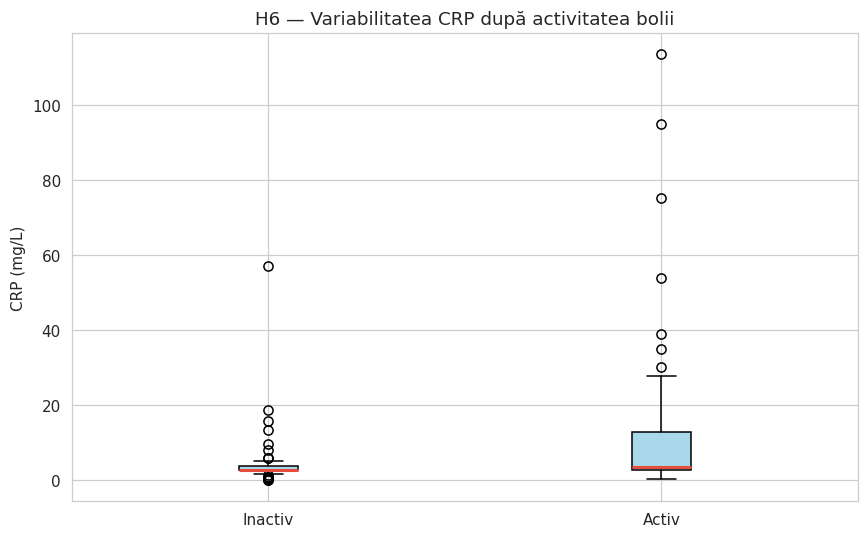

In [8]:
crp_active = df.loc[df["Boala_Activa"] == 1, "CRP_mgL"].dropna()
crp_inactive = df.loc[df["Boala_Activa"] == 0, "CRP_mgL"].dropna()

s1_sq = crp_active.var(ddof=1)
s2_sq = crp_inactive.var(ddof=1)
F = s1_sq / s2_sq
df1, df2 = len(crp_active)-1, len(crp_inactive)-1
p_one_sided = 1 - stats.f.cdf(F, df1, df2)

# Levene complementar (mai robust la non-normalitate)
levene_stat, levene_p = stats.levene(crp_active, crp_inactive, center="median")

print(f"Boală activă   : n = {len(crp_active)}, var = {s1_sq:.2f}, SD = {np.sqrt(s1_sq):.2f}")
print(f"Boală inactivă : n = {len(crp_inactive)}, var = {s2_sq:.2f}, SD = {np.sqrt(s2_sq):.2f}")
print(f"\nF Fisher = {F:.3f}  |  df = ({df1}, {df2})  |  p (unilateral, var₁ > var₂) = {p_one_sided:.4f}")
print(f"Levene (median) = {levene_stat:.3f}  |  p Levene = {levene_p:.4f}  [verificare robustă]")
print(f"Decizie F-test: {'Respingem H₀' if p_one_sided < ALPHA else 'NU respingem H₀'} (α = {ALPHA})")

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([crp_inactive, crp_active], labels=["Inactiv", "Activ"], patch_artist=True,
           boxprops=dict(facecolor="#a8d8ea"), medianprops=dict(color="#e74c3c", linewidth=2))
ax.set_title("H6 — Variabilitatea CRP după activitatea bolii")
ax.set_ylabel("CRP (mg/L)")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("figures/RA_S3_H6_Ftest_CRP_BoalaActiva.png", dpi=120, bbox_inches="tight")
plt.show()

**Interpretare H6:**
- F = s²₁ / s²₂; valoarea apropiată de 1 ⇒ varianțe similare, valoare mare ⇒ var₁ ≫ var₂.
- Dacă p_F < 0.05 (unilateral) → grupul activ are dispersie semnificativ mai mare ⇒ pacienții activi sunt **mai eterogeni** clinic.
- **Levene** este mai robust la non-normalitate: dacă concluziile celor două teste diferă, dăm **prioritate Levene** (CRP e clar asimetric).
- **Concluzia practică:** tratamentul individual este mai dificil de standardizat la pacienții cu boală activă (variabilitate mare) → necesită monitorizare frecventă și abordare personalizată.

## Sinteza rezultatelor

Tabelul de mai jos compilează automat toate cele 6 teste, cu statistica observată, valoarea p și decizia la α = 0.05. Este salvat și ca CSV în `output/Sarcina3_sumar_teste.csv`.

In [9]:
results = []

# H1
data = df["DAS28_CRP"].dropna(); mu0 = 5.1
t, p = stats.ttest_1samp(data, mu0)
results.append(("H1", "DAS28-CRP vs prag 5.1", "t one-sample", f"t={t:.3f}", f"{p:.4f}",
                "Respingem H₀" if p < 0.05 else "NU respingem H₀"))

# H2
g1 = df.loc[df.ACPA_Pozitiv == 1, "IL6_Nivel"].dropna()
g0 = df.loc[df.ACPA_Pozitiv == 0, "IL6_Nivel"].dropna()
t, p = stats.ttest_ind(g1, g0, equal_var=False)
results.append(("H2", "IL-6 ACPA+ vs ACPA−", "t Welch", f"t={t:.3f}", f"{p:.4f}",
                "Respingem H₀" if p < 0.05 else "NU respingem H₀"))

# H3
s = df.loc[df.Fumator == 1, "CRP_mgL"].dropna()
ns = df.loc[df.Fumator == 0, "CRP_mgL"].dropna()
U, p = stats.mannwhitneyu(s, ns, alternative="greater")
results.append(("H3", "CRP fumător > nefumător", "Mann–Whitney U", f"U={U:.0f}", f"{p:.4f}",
                "Respingem H₀" if p < 0.05 else "NU respingem H₀"))

# H4
ct = pd.crosstab(df.Sex_Feminin, df.ACPA_Pozitiv)
chi2, p, dof, _ = stats.chi2_contingency(ct, correction=False)
results.append(("H4", "Sex × ACPA (independență)", "χ² Pearson", f"χ²={chi2:.3f}", f"{p:.4f}",
                "Respingem H₀" if p < 0.05 else "NU respingem H₀"))

# H5
counts = np.array([df.loc[df.ACPA_Pozitiv == 1, "Boala_Activa"].sum(),
                   df.loc[df.ACPA_Pozitiv == 0, "Boala_Activa"].sum()])
nobs = np.array([(df.ACPA_Pozitiv == 1).sum(), (df.ACPA_Pozitiv == 0).sum()])
z, p = proportions_ztest(counts, nobs, alternative="larger")
results.append(("H5", "Boală activă: ACPA+ > ACPA−", "Z 2 proporții", f"z={z:.3f}", f"{p:.4f}",
                "Respingem H₀" if p < 0.05 else "NU respingem H₀"))

# H6
ca = df.loc[df.Boala_Activa == 1, "CRP_mgL"].dropna()
ci_ = df.loc[df.Boala_Activa == 0, "CRP_mgL"].dropna()
F = ca.var(ddof=1) / ci_.var(ddof=1)
p = 1 - stats.f.cdf(F, len(ca)-1, len(ci_)-1)
results.append(("H6", "Var(CRP) activ > inactiv", "Fisher F", f"F={F:.3f}", f"{p:.4f}",
                "Respingem H₀" if p < 0.05 else "NU respingem H₀"))

summary = pd.DataFrame(results, columns=["#", "Ipoteză", "Test", "Statistică", "p", "Decizie"])
print(summary.to_string(index=False))
summary.to_csv("output/Sarcina3_sumar_teste.csv", index=False)
print("\n→ Salvat: output/Sarcina3_sumar_teste.csv")
summary

 #                     Ipoteză           Test Statistică      p         Decizie
H1       DAS28-CRP vs prag 5.1   t one-sample  t=-10.210 0.0000    Respingem H₀
H2         IL-6 ACPA+ vs ACPA−        t Welch    t=2.031 0.0457    Respingem H₀
H3     CRP fumător > nefumător Mann–Whitney U      U=586 0.1653 NU respingem H₀
H4   Sex × ACPA (independență)     χ² Pearson   χ²=0.440 0.5073 NU respingem H₀
H5 Boală activă: ACPA+ > ACPA−  Z 2 proporții    z=3.267 0.0005    Respingem H₀
H6    Var(CRP) activ > inactiv       Fisher F    F=7.527 0.0000    Respingem H₀

→ Salvat: output/Sarcina3_sumar_teste.csv


,#,Ipoteză,Test,Statistică,p,Decizie
0,H1,DAS28-CRP vs prag 5.1,t one-sample,t=-10.210,0.0000,Respingem H₀
1,H2,IL-6 ACPA+ vs ACPA−,t Welch,t=2.031,0.0457,Respingem H₀
2,H3,CRP fumător > nefumător,Mann–Whitney U,U=586,0.1653,NU respingem H₀
3,H4,Sex × ACPA (independență),χ² Pearson,χ²=0.440,0.5073,NU respingem H₀
4,H5,Boală activă: ACPA+ > ACPA−,Z 2 proporții,z=3.267,0.0005,Respingem H₀
5,H6,Var(CRP) activ > inactiv,Fisher F,F=7.527,0.0000,Respingem H₀
